# Full ML Pipeline : EDA | Preprocessing | Modelling | Evaluation# Before doing anything, answer these questions:
- what is the exact question I am trying to answer?
- Is this a classification or regression problem(supervised)
- what is the target variable(y) (or column you are trying to predict)
- what are the features the model is going to use(X), (columns in x).
- what metrics are you going to use to measure sucess (metrics to use eg accuracy, precision of recall )
 
Explanatory Data Analysis
1. Understand the structure and the quality of your dataset.
2. identify the missing values, outliers and class inbalance(this is where when you look at your y one class has so many values compared to the other ie 80/20).
3. Visualize distributions and relationships between features. heat maps, bar charts.
 
EDA checklist
1. Load and inspect.
python
    df.head()
    df.shape
    df.dtypes
    df.info()
 
no. of rows/columns, data types, and obvious issues eg missing
 
2. Summary Statistics
python
    df.describe() gives the range, the means the extremes, max, min,
 
3. Missing Values
python
    df.isnull().sum()
 
which column is missing, how much, pattern or random.
4. Check the Target Distribution
python
    df[target].value_counts()
 
show class imbalance, whether one has skewed dist etc
5. Feature Distribution
df.hist() or sns.boxplot() , normal, skewed or has outliers.
 
6. Correlations
df.corr() + heatmap
Highly correlated features,
 
7. Feature vs target
Scatter plots, boxplots per class

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# read the data
data = pd.read_csv('Titanic_Dataset.csv')

In [7]:
data.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [10]:
# Summary Statistics
print("Summary Statistics:")
print(data.describe().round(2))



Summary Statistics:
       PassengerId  Survived  Pclass     Age   SibSp   Parch    Fare
count       891.00    891.00  891.00  714.00  891.00  891.00  891.00
mean        446.00      0.38    2.31   29.70    0.52    0.38   32.20
std         257.35      0.49    0.84   14.53    1.10    0.81   49.69
min           1.00      0.00    1.00    0.42    0.00    0.00    0.00
25%         223.50      0.00    2.00   20.12    0.00    0.00    7.91
50%         446.00      0.00    3.00   28.00    0.00    0.00   14.45
75%         668.50      1.00    3.00   38.00    1.00    0.00   31.00
max         891.00      1.00    3.00   80.00    8.00    6.00  512.33


In [11]:
#3. Missing values.
print("Missing values: ")
missing = data.isnull().sum()
missing_pct = data.isnull().mean() * 100

missing_df = pd.DataFrame({
    'count': missing, 
    'percentage': missing_pct
})

print(missing_df[missing_df['count'] > 0 ].sort_values('percentage', 
                                                       ascending=False))

Missing values: 
          count  percentage
Cabin       687   77.104377
Age         177   19.865320
Embarked      2    0.224467


In [12]:
TARGET = 'Survived'
print("Target Distribution:")
print(data[TARGET].value_counts())
print(data[TARGET].value_counts(normalize=True).round(2))

Target Distribution:
Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    0.62
1    0.38
Name: proportion, dtype: float64


In [13]:
#3. Missing values.
print("Missing values: ")
missing = data.isnull().sum()
missing_pct = data.isnull().mean() * 100

missing_df = pd.DataFrame({
    'count': missing, 
    'percentage': missing_pct
})

print(missing_df[missing_df['count'] > 0 ].sort_values('percentage', 
                                                       ascending=False))

Missing values: 
          count  percentage
Cabin       687   77.104377
Age         177   19.865320
Embarked      2    0.224467


In [14]:
# 4. Target distribution.
TARGET = 'Survived'
print("Target distribution")
print(data[TARGET].value_counts())
print(data[TARGET].value_counts(normalize=True).round(3)) # to see class Imbalance

# Imbalance > 80/20 needs some handling.

Target distribution
Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


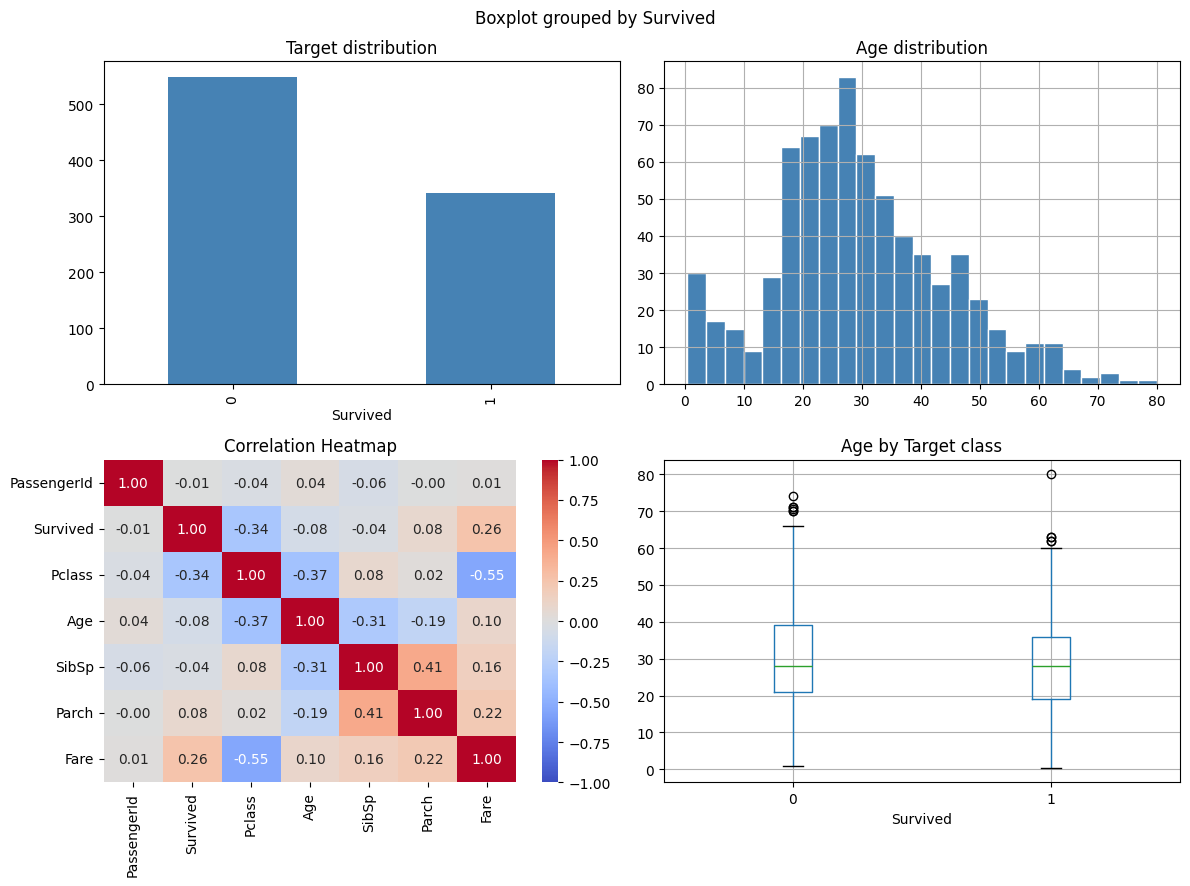

EDA complete


In [15]:
# 5. Visualizations.
fig, axes = plt.subplots(2, 2, figsize= (12, 9))

# Target distribution
data[TARGET].value_counts().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Target distribution')

# feature distribution (age)
data['Age'].dropna().hist(ax=axes[0,1], bins=25, color='steelblue', edgecolor='white')
axes[0,1].set_title('Age distribution')

# correlation heatmap (numerical columns only)
num_cols = data.select_dtypes(include=np.number).columns
sns.heatmap(data[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,0], vmin=-1,
             vmax=1)
axes[1,0].set_title('Correlation Heatmap')

# Feature vs target (age vs survived)
data.boxplot(column='Age', by=TARGET, ax=axes[1,1])
axes[1,1].set_title('Age by Target class')

plt.tight_layout()
plt.show()
print("EDA complete") # Make sure you note your findings before proceeding.

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


In [19]:
# 1. select and clean columns
data_clean = data.copy()

# Drop columns that we are not going to use.
cols_to_drop = ['PassengerId', "Name", "Cabin", "Ticket", "doesntExist"]
data_clean = data_clean.drop(columns=[c for c in cols_to_drop if c in data_clean])

In [21]:
# Separating features from target
TARGET = 'Survived'
X = data_clean.drop(columns=[TARGET])
y = data_clean[TARGET]

In [22]:
print(f"Features remaining: {list[X.columns]}")
print(f"Shape of features: {X.shape}")
print(f"The target: {TARGET}")

Features remaining: list[Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'], dtype='str')]
Shape of features: (891, 7)
The target: Survived


In [23]:
# splitting then preprocessing, 
# stratify- ensures that your training and 
# testing sets maintain the same class proportions as the original dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, 
                                                    stratify=y)
print(f"Train: {X_train.shape} Test: {X_test.shape}")

Train: (712, 7) Test: (179, 7)


In [24]:
# Identify column types
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['str']).columns.tolist()

print(f'Numerical: {num_cols}')
print(f"Categorical: {cat_cols}")

Numerical: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical: ['Sex', 'Embarked']


In [25]:
# Building the pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

X_tr_transformed = preprocessor.fit_transform(X_train)
print(f'After preprocessing X trained: {X_tr_transformed.shape}')
print("Ready to add model if no errors")

After preprocessing X trained: (712, 8)
Ready to add model if no errors


In [26]:
X['Sex'].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

In [28]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'KNN': KNeighborsClassifier()
}

In [29]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [30]:
# training in pipeline
results = {}
for name, model in models.items():
    full_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model) 
    ])

    # Accuracy
    acc_scores = cross_val_score(full_pipe, X_train, y_train, cv=cv, scoring='accuracy')
    f1_scores = cross_val_score(full_pipe, X_train, y_train, cv=cv, scoring='f1')

    # Saving the results.
    results[name] = {'acc': acc_scores.mean(), 'f1':f1_scores.mean()}

    print(f"{name:<25} {acc_scores.mean()} {acc_scores.std()} {f1_scores.mean()}")


Logistic Regression       0.7949374569092879 0.02727663790298474 0.7246353792381143
Random Forest             0.794937456909288 0.015098603237695915 0.7288683145600695
Gradient Boosting         0.8258347286516299 0.035418596033379046 0.7587872046093072
KNN                       0.7977839062346105 0.021180688430028526 0.721238400224206


In [31]:
results

{'Logistic Regression': {'acc': np.float64(0.7949374569092879),
  'f1': np.float64(0.7246353792381143)},
 'Random Forest': {'acc': np.float64(0.794937456909288),
  'f1': np.float64(0.7288683145600695)},
 'Gradient Boosting': {'acc': np.float64(0.8258347286516299),
  'f1': np.float64(0.7587872046093072)},
 'KNN': {'acc': np.float64(0.7977839062346105),
  'f1': np.float64(0.721238400224206)}}

In [32]:
best_name = max(results, key=lambda k: results[k]['f1'])
print(f"Best model is {best_name}")

Best model is Gradient Boosting


In [33]:
# Tuning the best model - Let's tune random forest for learning purposes.
# Also RandomForest was the most stable
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'model__n_estimators': randint(50, 400),
    'model__max_depth': randint(2, 25),
    'model__min_samples_split': randint(2, 15),
    'model__min_samples_leaf': randint(1, 8)
}

best_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

search = RandomizedSearchCV(best_pipe, param_distributions=param_dist, n_iter=50, 
                            cv=5, scoring='f1', n_jobs=-1, random_state=42, verbose=1)
search.fit(X_train, y_train)

print(f"Best cv f1: {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best cv f1: 0.7589
Best params: {'model__max_depth': 22, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 141}


In [34]:
# Final evaluation.
final_model = search.best_estimator_
final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [35]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_pred = final_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.89      0.84       110
           1       0.79      0.65      0.71        69

    accuracy                           0.80       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179



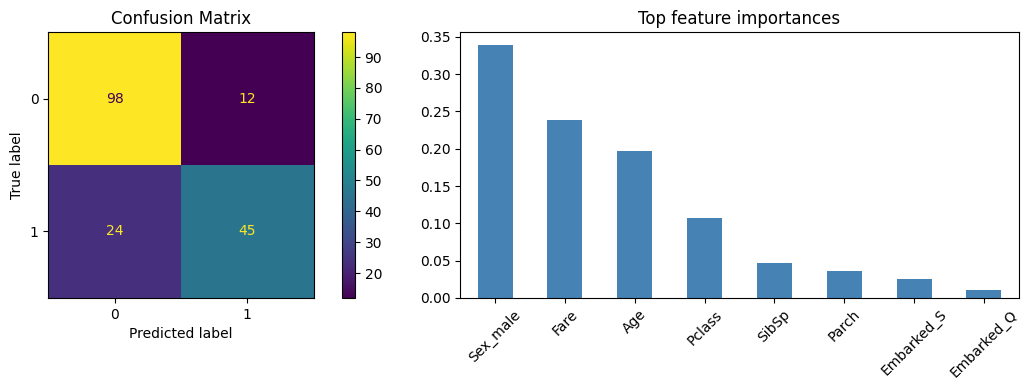

In [36]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize= (12, 4))

# Left plot: Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0])
axes[0].set_title('Confusion Matrix')

# right plot
if hasattr(final_model['model'], 'feature_importances_'):
    #1. Extract feature names 
    num_names = num_cols
    cat_names = (final_model['preprocessor']
                 .named_transformers_['cat']['encoder']
                 .get_feature_names_out(cat_cols).tolist())
    all_names = num_names + cat_names

    #2. Map importances to names
    importances = pd.Series(final_model['model'].feature_importances_, 
                            index=all_names).sort_values(ascending=False)
    
    #3. Plot (bar)
    importances.plot(kind='bar', ax=axes[1], color='steelblue')
    axes[1].set_title('Top feature importances')
    axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()